In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

pd.set_option('display.width', None)

df_skewness = pd.read_parquet('data/processed/skewness_analysis.parquet')

df_skewness.tail()

,secid,Date,days,upperSKEW,lowerSKEW,SKEW,variance
27847,108105,2023-08-30,365,0.000190,-0.008759,-0.008569,0.023341
27848,108105,2023-08-31,30,0.000102,-0.000594,-0.000492,0.010111
27849,108105,2023-08-31,91,0.000169,-0.001979,-0.001810,0.013959
27850,108105,2023-08-31,182,0.000192,-0.004002,-0.003810,0.017457
27851,108105,2023-08-31,365,0.000216,-0.008596,-0.008379,0.023838


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

pd.set_option('display.width', None)

df = pd.read_parquet('data/processed/options_fomc_panel_1996_2023.parquet')

df.head()

,secid,Date,cp_flag,delta,days,impl_volatility,impl_premium,impl_strike,fomc_dummy,vix,rf_rate,spx_price,monetary_policy_shock,T_years,dividend_yield,forwardprice,vix_stress_75
0,108105.0,1996-01-04,C,10.0,30.0,0.096883,0.803134,642.7569,0.0,13.78,5.19,617.7,NaN,0.082192,0.0,620.340584,0
1,108105.0,1996-01-04,C,15.0,30.0,0.098895,1.343892,638.7863,0.0,13.78,5.19,617.7,NaN,0.082192,0.0,620.340584,0
2,108105.0,1996-01-04,C,20.0,30.0,0.100675,1.963859,635.5488,0.0,13.78,5.19,617.7,NaN,0.082192,0.0,620.340584,0
3,108105.0,1996-01-04,C,25.0,30.0,0.101514,2.643503,632.5961,0.0,13.78,5.19,617.7,NaN,0.082192,0.0,620.340584,0
4,108105.0,1996-01-04,C,30.0,30.0,0.102137,3.392095,629.8998,0.0,13.78,5.19,617.7,NaN,0.082192,0.0,620.340584,0


In [3]:
import statsmodels.api as sm

# -------------------------------------------------------------------
# Data loading and preprocessing
# -------------------------------------------------------------------
option_panel = pd.read_parquet("./data/processed/options_fomc_panel_1996_2023.parquet")
df_skewness = pd.read_parquet("./data/processed/skewness_analysis.parquet")

option_panel["vix"] = option_panel["vix"] / 100.0
option_panel["secid"] = option_panel["secid"].astype(int)

# Identify FOMC dates and construct event window (one trading day before and after)
fomc_dates = pd.to_datetime(option_panel[option_panel["fomc_dummy"] == 1]["Date"]).dt.normalize().drop_duplicates().sort_values().tolist()
all_dates = pd.to_datetime(option_panel["Date"]).dt.normalize().drop_duplicates().sort_values().tolist()

event_data = []
for date in fomc_dates:
    if date in all_dates:
        idx = all_dates.index(date)
        prev_date = all_dates[idx - 1] if idx > 0 else None
        next_date = all_dates[idx + 1] if idx < len(all_dates) - 1 else None
        event_data.append({"event_date": date, "prev_date": prev_date, "next_date": next_date})
events_df = pd.DataFrame(event_data)

# Prepare skewness changes (retain secid and days)
prev_skew = df_skewness.rename(columns={
    "Date": "prev_date", "SKEW": "SKEW_prev", "upperSKEW": "upperSKEW_prev",
    "lowerSKEW": "lowerSKEW_prev", "variance": "variance_prev"
})
next_skew = df_skewness.rename(columns={
    "Date": "next_date", "SKEW": "SKEW_next", "upperSKEW": "upperSKEW_next",
    "lowerSKEW": "lowerSKEW_next", "variance": "variance_next"
})

event_skew = events_df.merge(prev_skew, on="prev_date", how="left") \
                      .merge(next_skew, on=["next_date", "secid", "days"], how="left")

# Compute skewness changes
event_skew["dLowerSKEW"] = event_skew["lowerSKEW_next"] - event_skew["lowerSKEW_prev"]
event_skew["dUpperSKEW"] = event_skew["upperSKEW_next"] - event_skew["upperSKEW_prev"]

# Compute ΔVIX (VIX change around the announcement)
# First get daily VIX (multiple records per date per secid, take first)
daily_vix = option_panel[["Date", "secid", "vix"]].drop_duplicates(subset=["Date", "secid"])
prev_vix = daily_vix.rename(columns={"Date": "prev_date", "vix": "vix_prev"})
next_vix = daily_vix.rename(columns={"Date": "next_date", "vix": "vix_next"})
event_skew = event_skew.merge(prev_vix, on=["prev_date", "secid"], how="left") \
                       .merge(next_vix, on=["next_date", "secid"], how="left")
event_skew["dVIX"] = event_skew["vix_next"] - event_skew["vix_prev"]

# Keep required columns
event_skew = event_skew[["secid", "event_date", "days", "dLowerSKEW", "dUpperSKEW", "vix_prev", "dVIX"]].rename(
    columns={"event_date": "Date", "vix_prev": "vix"}
)

# -------------------------------------------------------------------
# Prepare regression data: merge MPS variables on FOMC dates
# -------------------------------------------------------------------
option_panel_reg = option_panel[option_panel["fomc_dummy"] == 1][
    ["secid", "Date", "monetary_policy_shock", "fomc_dummy"]
].drop_duplicates(subset=["secid", "Date"])

option_panel_reg = option_panel_reg.merge(event_skew, on=["secid", "Date"], how="right")

# Create positive/negative shocks and interaction terms
option_panel_reg["mps"] = option_panel_reg["monetary_policy_shock"]
option_panel_reg["mps_pos"] = np.maximum(option_panel_reg["mps"], 0)
option_panel_reg["mps_neg"] = np.minimum(option_panel_reg["mps"], 0)
option_panel_reg["mps_pos_x_vix"] = option_panel_reg["mps_pos"] * option_panel_reg["vix"]
option_panel_reg["mps_neg_x_vix"] = option_panel_reg["mps_neg"] * option_panel_reg["vix"]

# -------------------------------------------------------------------
# Regression function definitions
# -------------------------------------------------------------------
def run_model1a(df, dep_var):
    """Model 1a: continuous MPS only"""
    X = sm.add_constant(df[["mps"]])
    y = df[dep_var]
    return sm.OLS(y, X, missing="drop").fit()

def run_model1b(df, dep_var):
    """Model 1b: separate MPS^+, MPS^-"""
    X = sm.add_constant(df[["mps_pos", "mps_neg"]])
    y = df[dep_var]
    return sm.OLS(y, X, missing="drop").fit()

def run_model2(df, dep_var):
    """Model 2: MPS^+, MPS^-, VIX, interactions"""
    X = sm.add_constant(df[["mps_pos", "mps_neg", "vix", "mps_pos_x_vix", "mps_neg_x_vix"]])
    y = df[dep_var]
    return sm.OLS(y, X, missing="drop").fit()

def run_model3(df, dep_var):
    """Model 3: Model 2 + dVIX control"""
    X = sm.add_constant(df[["mps_pos", "mps_neg", "vix", "mps_pos_x_vix", "mps_neg_x_vix", "dVIX"]])
    y = df[dep_var]
    return sm.OLS(y, X, missing="drop").fit()

# -------------------------------------------------------------------
# Store results
# -------------------------------------------------------------------
maturities = [30, 91, 182, 365]
dep_vars = ["dLowerSKEW", "dUpperSKEW"]

results = {
    "model1a": {m: {dv: None for dv in dep_vars} for m in maturities},
    "model1b": {m: {dv: None for dv in dep_vars} for m in maturities},
    "model2":  {m: {dv: None for dv in dep_vars} for m in maturities},
    "model3":  {m: {dv: None for dv in dep_vars} for m in maturities},
}

for maturity in maturities:
    df_m = option_panel_reg[option_panel_reg["days"] == maturity].copy()
    for dv in dep_vars:
        results["model1a"][maturity][dv] = run_model1a(df_m, dv)
        results["model1b"][maturity][dv] = run_model1b(df_m, dv)
        results["model2"][maturity][dv] = run_model2(df_m, dv)
        results["model3"][maturity][dv] = run_model3(df_m, dv)

# -------------------------------------------------------------------
# Generate three separate LaTeX tables
# -------------------------------------------------------------------
def generate_table_1(res1a, res1b, maturities, dep_vars):
    """Table 1: Panel A continuous MPS, Panel B separated positive/negative"""
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{FOMC Window Changes in Skewness: Baseline Specifications}")
    lines.append(r"\label{tab:skewness_baseline}")
    lines.append(r"\begin{tabular*}{\textwidth}{l@{\extracolsep{\fill}}*{8}{c}}")
    lines.append(r"\toprule")
    header = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{m} days}}" for m in maturities]) + r" \\"
    lines.append(header)
    lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}")
    subheader = " & " + " & ".join([r"$\Delta$Lower & $\Delta$Upper"] * len(maturities)) + r" \\"
    lines.append(subheader)
    lines.append(r"\midrule")
    
    # Panel A: Continuous MPS
    lines.append(r"\multicolumn{9}{l}{\textbf{Panel A: Continuous MPS}} \\")
    lines.append(r"\midrule")
    var_order = ["const", "mps"]
    var_names = {"const": "Constant", "mps": "MPS"}
    for var in var_order:
        coef_line = var_names[var]
        t_line = ""
        for m in maturities:
            for dv in dep_vars:
                res = res1a[m][dv]
                if var in res.params:
                    coef = f"{res.params[var]:.3f}"
                    tval = f"({res.tvalues[var]:.2f})"
                else:
                    coef, tval = "", ""
                coef_line += f" & {coef}"
                t_line += f" & {tval}"
        coef_line += r" \\"
        t_line += r" \\"
        lines.append(coef_line)
        lines.append(t_line)
    
    lines.append(r"\midrule")
    lines.append(r"\multicolumn{9}{l}{\textbf{Panel B: Separated MPS$^+$ and MPS$^-$}} \\")
    lines.append(r"\midrule")
    var_order2 = ["const", "mps_pos", "mps_neg"]
    var_names2 = {"const": "Constant", "mps_pos": "MPS$^+$", "mps_neg": "MPS$^-$"}
    for var in var_order2:
        coef_line = var_names2[var]
        t_line = ""
        for m in maturities:
            for dv in dep_vars:
                res = res1b[m][dv]
                if var in res.params:
                    coef = f"{res.params[var]:.3f}"
                    tval = f"({res.tvalues[var]:.2f})"
                else:
                    coef, tval = "", ""
                coef_line += f" & {coef}"
                t_line += f" & {tval}"
        coef_line += r" \\"
        t_line += r" \\"
        lines.append(coef_line)
        lines.append(t_line)
    
    lines.append(r"\midrule")
    # N and R²
    n_line = "N"
    for m in maturities:
        n = res1a[m][dep_vars[0]].nobs
        n_line += f" & \\multicolumn{{2}}{{c}}{{{int(n)}}}"
    n_line += r" \\"
    lines.append(n_line)
    r1a_line = "R² (Panel A)"
    for m in maturities:
        r_lower = f"{res1a[m]['dLowerSKEW'].rsquared:.3f}"
        r_upper = f"{res1a[m]['dUpperSKEW'].rsquared:.3f}"
        r1a_line += f" & {r_lower} & {r_upper}"
    r1a_line += r" \\"
    lines.append(r1a_line)
    r1b_line = "R² (Panel B)"
    for m in maturities:
        r_lower = f"{res1b[m]['dLowerSKEW'].rsquared:.3f}"
        r_upper = f"{res1b[m]['dUpperSKEW'].rsquared:.3f}"
        r1b_line += f" & {r_lower} & {r_upper}"
    r1b_line += r" \\"
    lines.append(r1b_line)
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular*}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

def generate_table_2(res2, maturities, dep_vars):
    """Table 2: With VIX and interactions"""
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{FOMC Window Changes in Skewness: With VIX and Interactions}")
    lines.append(r"\label{tab:skewness_vix_interaction}")
    lines.append(r"\begin{tabular*}{\textwidth}{l@{\extracolsep{\fill}}*{8}{c}}")
    lines.append(r"\toprule")
    header = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{m} days}}" for m in maturities]) + r" \\"
    lines.append(header)
    lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}")
    subheader = " & " + " & ".join([r"$\Delta$Lower & $\Delta$Upper"] * len(maturities)) + r" \\"
    lines.append(subheader)
    lines.append(r"\midrule")
    
    var_order = ["const", "mps_pos", "mps_neg", "vix", "mps_pos_x_vix", "mps_neg_x_vix"]
    var_names = {
        "const": "Constant", "mps_pos": "MPS$^+$", "mps_neg": "MPS$^-$",
        "vix": "VIX", "mps_pos_x_vix": "MPS$^+$ $\\times$ VIX",
        "mps_neg_x_vix": "MPS$^-$ $\\times$ VIX"
    }
    for var in var_order:
        coef_line = var_names[var]
        t_line = ""
        for m in maturities:
            for dv in dep_vars:
                res = res2[m][dv]
                if var in res.params:
                    coef = f"{res.params[var]:.3f}"
                    tval = f"({res.tvalues[var]:.2f})"
                else:
                    coef, tval = "", ""
                coef_line += f" & {coef}"
                t_line += f" & {tval}"
        coef_line += r" \\"
        t_line += r" \\"
        lines.append(coef_line)
        lines.append(t_line)
    
    lines.append(r"\midrule")
    n_line = "N"
    for m in maturities:
        n = res2[m][dep_vars[0]].nobs
        n_line += f" & \\multicolumn{{2}}{{c}}{{{int(n)}}}"
    n_line += r" \\"
    lines.append(n_line)
    r2_line = "R²"
    for m in maturities:
        r_lower = f"{res2[m]['dLowerSKEW'].rsquared:.3f}"
        r_upper = f"{res2[m]['dUpperSKEW'].rsquared:.3f}"
        r2_line += f" & {r_lower} & {r_upper}"
    r2_line += r" \\"
    lines.append(r2_line)
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular*}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

def generate_table_3(res3, maturities, dep_vars):
    """Table 3: Model 2 + ΔVIX control"""
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{FOMC Window Changes in Skewness: Adding $\Delta$VIX as Control}")
    lines.append(r"\label{tab:skewness_deltavix}")
    lines.append(r"\begin{tabular*}{\textwidth}{l@{\extracolsep{\fill}}*{8}{c}}")
    lines.append(r"\toprule")
    header = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{m} days}}" for m in maturities]) + r" \\"
    lines.append(header)
    lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}")
    subheader = " & " + " & ".join([r"$\Delta$Lower & $\Delta$Upper"] * len(maturities)) + r" \\"
    lines.append(subheader)
    lines.append(r"\midrule")
    
    var_order = ["const", "mps_pos", "mps_neg", "vix", "mps_pos_x_vix", "mps_neg_x_vix", "dVIX"]
    var_names = {
        "const": "Constant", "mps_pos": "MPS$^+$", "mps_neg": "MPS$^-$",
        "vix": "VIX", "mps_pos_x_vix": "MPS$^+$ $\\times$ VIX",
        "mps_neg_x_vix": "MPS$^-$ $\\times$ VIX", "dVIX": "$\Delta$VIX"
    }
    for var in var_order:
        coef_line = var_names[var]
        t_line = ""
        for m in maturities:
            for dv in dep_vars:
                res = res3[m][dv]
                if var in res.params:
                    coef = f"{res.params[var]:.3f}"
                    tval = f"({res.tvalues[var]:.2f})"
                else:
                    coef, tval = "", ""
                coef_line += f" & {coef}"
                t_line += f" & {tval}"
        coef_line += r" \\"
        t_line += r" \\"
        lines.append(coef_line)
        lines.append(t_line)
    
    lines.append(r"\midrule")
    n_line = "N"
    for m in maturities:
        n = res3[m][dep_vars[0]].nobs
        n_line += f" & \\multicolumn{{2}}{{c}}{{{int(n)}}}"
    n_line += r" \\"
    lines.append(n_line)
    r3_line = "R²"
    for m in maturities:
        r_lower = f"{res3[m]['dLowerSKEW'].rsquared:.3f}"
        r_upper = f"{res3[m]['dUpperSKEW'].rsquared:.3f}"
        r3_line += f" & {r_lower} & {r_upper}"
    r3_line += r" \\"
    lines.append(r3_line)
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular*}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

# Output three tables
print(generate_table_1(results["model1a"], results["model1b"], maturities, dep_vars))
print(generate_table_2(results["model2"], maturities, dep_vars))
print(generate_table_3(results["model3"], maturities, dep_vars))

<>:293: SyntaxWarning: invalid escape sequence '\D'
<>:293: SyntaxWarning: invalid escape sequence '\D'
C:\Users\71415\AppData\Local\Temp\ipykernel_30344\1227909172.py:293: SyntaxWarning: invalid escape sequence '\D'
  "mps_neg_x_vix": "MPS$^-$ $\\times$ VIX", "dVIX": "$\Delta$VIX"


\begin{table}[htbp]
\centering
\caption{FOMC Window Changes in Skewness: Baseline Specifications}
\label{tab:skewness_baseline}
\begin{tabular*}{\textwidth}{l@{\extracolsep{\fill}}*{8}{c}}
\toprule
 & \multicolumn{2}{c}{30 days} & \multicolumn{2}{c}{91 days} & \multicolumn{2}{c}{182 days} & \multicolumn{2}{c}{365 days} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
 & $\Delta$Lower & $\Delta$Upper & $\Delta$Lower & $\Delta$Upper & $\Delta$Lower & $\Delta$Upper & $\Delta$Lower & $\Delta$Upper \\
\midrule
\multicolumn{9}{l}{\textbf{Panel A: Continuous MPS}} \\
\midrule
Constant & 0.000 & -0.000 & 0.000 & -0.000 & 0.000 & -0.000 & 0.000 & -0.000 \\
 & (1.31) & (-1.16) & (1.39) & (-1.25) & (1.24) & (-1.23) & (1.44) & (-1.03) \\
MPS & -0.009 & 0.003 & -0.009 & 0.003 & -0.005 & 0.002 & -0.007 & 0.002 \\
 & (-3.91) & (4.54) & (-2.58) & (3.84) & (-1.81) & (3.10) & (-2.81) & (3.46) \\
\midrule
\multicolumn{9}{l}{\textbf{Panel B: Separated MPS$^+$ and MPS$^-$}} \\

<>:158: SyntaxWarning: invalid escape sequence '\D'
<>:158: SyntaxWarning: invalid escape sequence '\D'
C:\Users\71415\AppData\Local\Temp\ipykernel_30344\3029536558.py:158: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('Marginal effect on $\Delta$Lower Skewness')


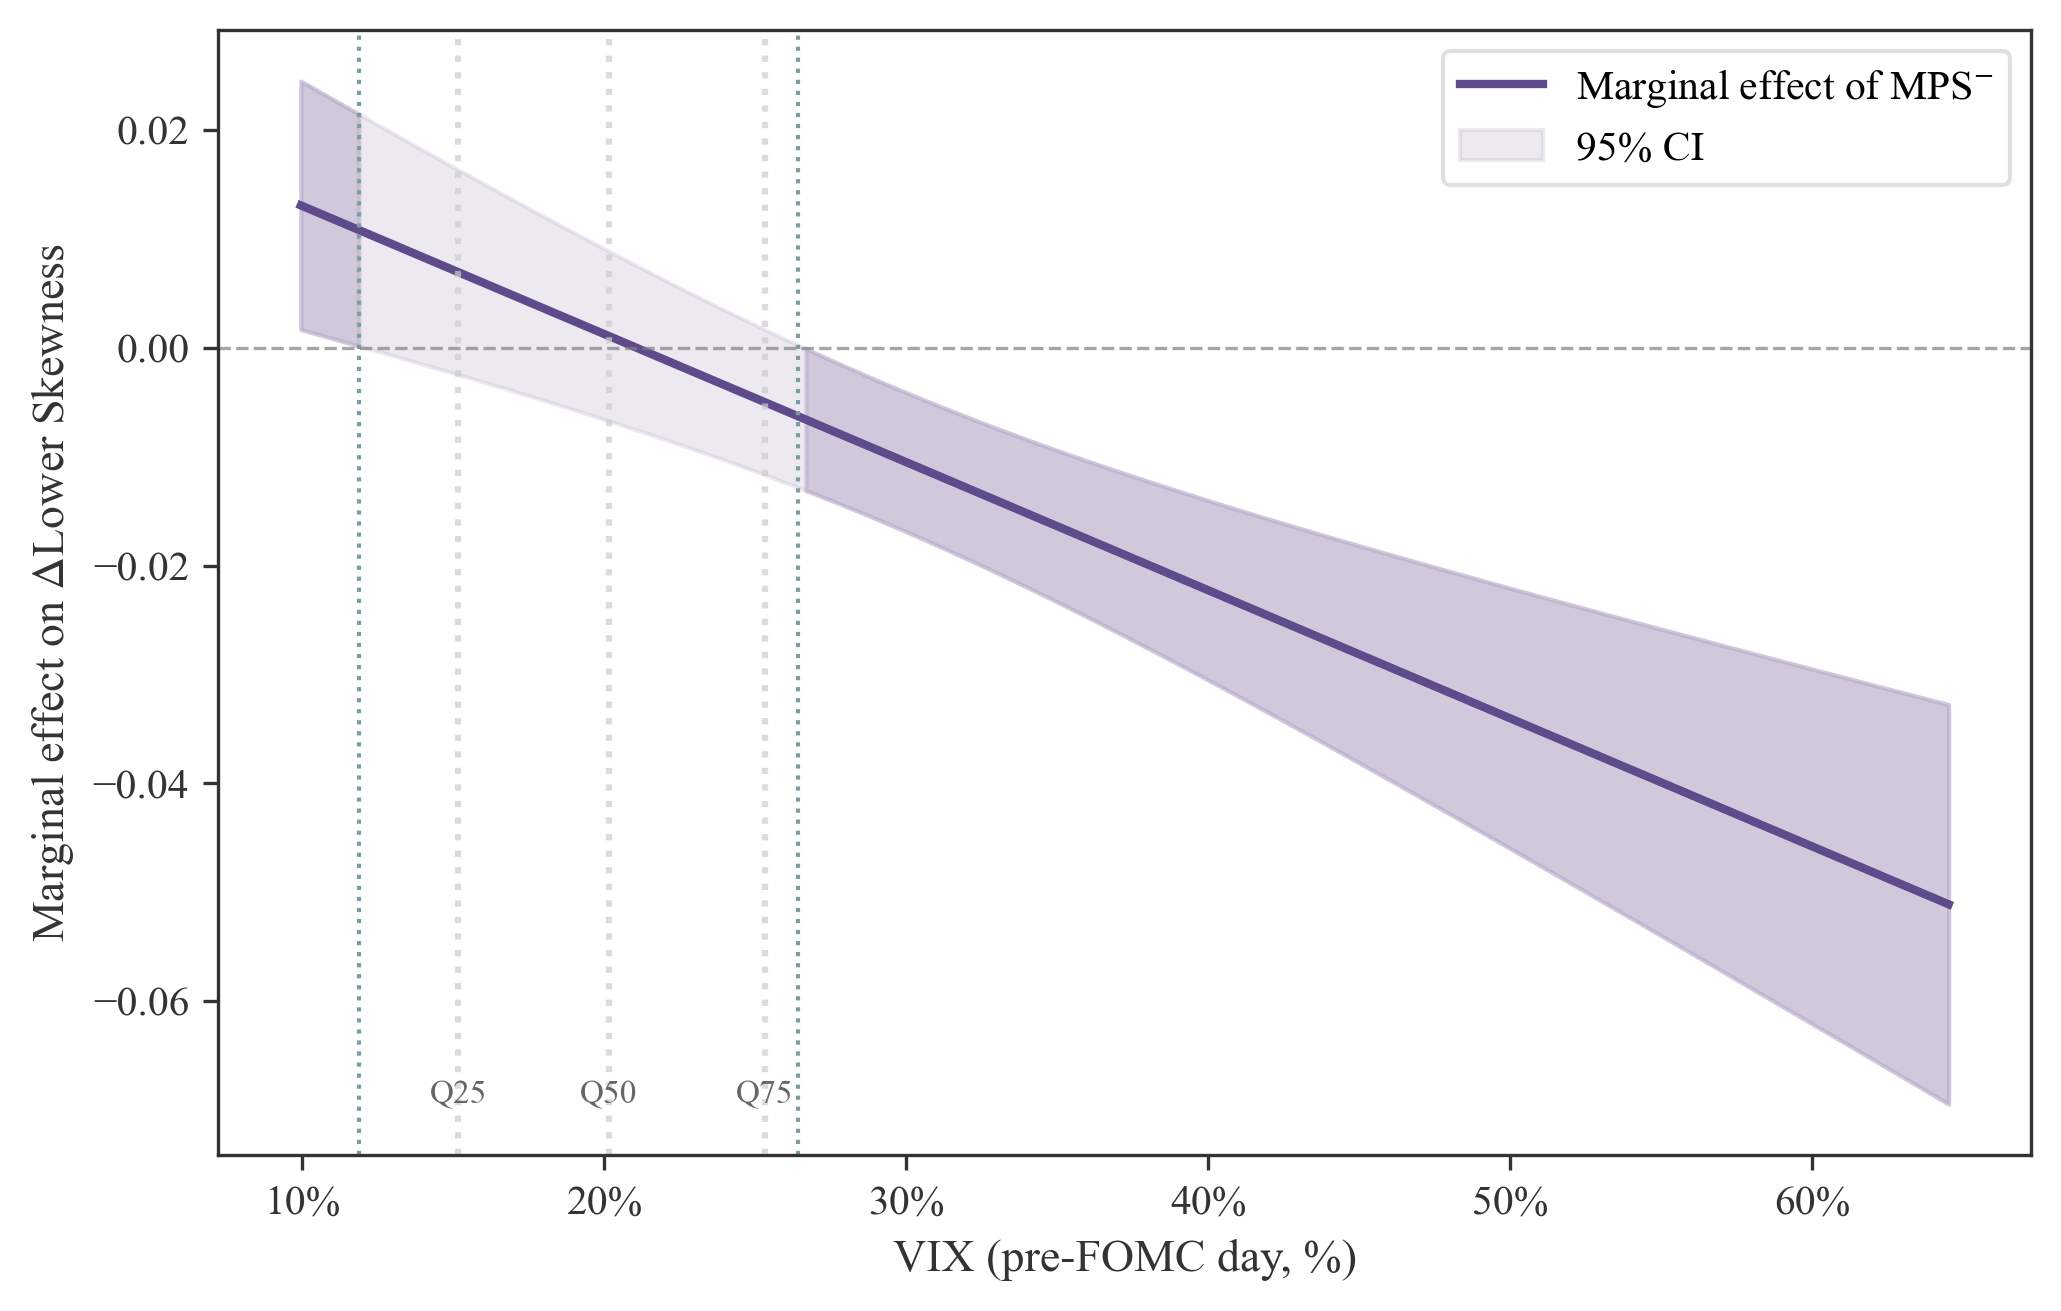

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from matplotlib import rcParams
import os
import warnings
warnings.filterwarnings("ignore")

# ==================== Updated Pantone color scheme ====================
PANTONE_COLORS = {
    # Main tones - Pantone Color of the Year
    'ultra_violet_2018': '#5F4B8B',  # Pantone 2018 Color of the Year - Ultra Violet
    'peach_fuzz_2024': '#FFBE98',    # Pantone 2024 Color of the Year - Peach Fuzz

    # Modern auxiliary colors
    'soft_teal': '#7A9E9F',      # Soft celadon - replaces dark blue
    'dusty_lavender': '#B8A9C9',   # Dusty lavender purple
    'warm_sand': '#D7CEC7',       # Warm sand color
    'pale_moss': '#C8D5B9',       # Pale moss green
    'misty_blue': '#96B3D0'       # Misty blue
}

# ==================== Academic-level chart configuration ====================
def set_academic_style():
    """Set chart style suitable for academic papers"""
    rcParams.update({
        # Font settings
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 11,
        'mathtext.fontset': 'stix',

        # Figure size (suitable for paper layout)
        'figure.figsize': (6.5, 4.5),
        'figure.dpi': 300,

        # Axes settings
        'axes.linewidth': 0.8,
        'axes.edgecolor': '#333333',
        'axes.labelcolor': '#333333',
        'axes.titlesize': 12,
        'axes.labelsize': 11,

        # Tick settings
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.color': '#333333',
        'ytick.color': '#333333',
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,

        # Legend settings
        'legend.fontsize': 10,
        'legend.frameon': True,
        'legend.framealpha': 0.9,
        'legend.edgecolor': '#DDDDDD',

        # Grid settings
        'grid.color': '#EEEEEE',
        'grid.linestyle': '-',
        'grid.linewidth': 0.7,
        'grid.alpha': 0.8,

        # Line settings
        'lines.linewidth': 1.5,
        'lines.markersize': 4,

        # Saving settings (LaTeX compatible)
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'savefig.format': 'png'
    })


# ------------------------------------------------------------
# 1. Extract model results and compute marginal effects
# ------------------------------------------------------------
model = results["model2"][30]["dLowerSKEW"]   # 30 days, ΔLower Skewness

# Obtain coefficients and covariance matrix
beta = model.params
vcov = model.cov_params()

# Marginal effect of the interaction term mps_neg × vix: β_mps_neg + β_mps_neg_x_vix * VIX
b_mps_neg = beta["mps_neg"]                 # β₂
b_inter   = beta["mps_neg_x_vix"]           # β₅
var_b2  = vcov.loc["mps_neg", "mps_neg"]
var_b5  = vcov.loc["mps_neg_x_vix", "mps_neg_x_vix"]
cov_b2_b5 = vcov.loc["mps_neg", "mps_neg_x_vix"]

# Determine the range of VIX (based on sample; note that regression uses VIX value on the day before the announcement)
# option_panel_reg already contains the vix column (i.e., vix_prev) and is filtered for days == 30
df_30 = option_panel_reg[option_panel_reg["days"] == 30].copy()
vix_sample = df_30["vix"].dropna()
vix_min = vix_sample.quantile(0.005)   # avoid extreme values
vix_max = vix_sample.quantile(0.995)
vix_grid = np.linspace(vix_min, vix_max, 200)

# Compute marginal effect and its standard error
marginal_effect = b_mps_neg + b_inter * vix_grid
se = np.sqrt(var_b2 + (vix_grid**2) * var_b5 + 2 * vix_grid * cov_b2_b5)

# t-statistic and confidence interval (two-tailed 95%)
t_crit = model.df_resid  # degrees of freedom
t_crit_val = 1.96  # approximate normal; for large samples 1.96 is fine; more rigorous: scipy.stats.t.ppf(0.975, df)
from scipy.stats import t as t_dist
t_critical = t_dist.ppf(0.975, model.df_resid)
ci_lower = marginal_effect - t_critical * se
ci_upper = marginal_effect + t_critical * se

# Identify regions where the effect is significant (CI does not contain 0)
significance = (ci_lower > 0) | (ci_upper < 0)

# ------------------------------------------------------------
# 2. Generate visualization (with corrected VIX range)
# ------------------------------------------------------------
set_academic_style()
os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Marginal effect line
ax.plot(vix_grid, marginal_effect, color=PANTONE_COLORS['ultra_violet_2018'],
        linewidth=2, label='Marginal effect of MPS$^{-}$')

# 95% confidence interval (alpha=0.5)
ax.fill_between(vix_grid, ci_lower, ci_upper,
                color=PANTONE_COLORS['dusty_lavender'], alpha=0.25,
                label='95% CI')

# Highlight significant regions
if np.any(significance):
    sig_mask = significance.astype(int)
    changes = np.diff(sig_mask, prepend=0, append=0)
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0] - 1
    for s, e in zip(starts, ends):
        ax.fill_between(vix_grid[s:e+1], ci_lower[s:e+1], ci_upper[s:e+1],
                        color=PANTONE_COLORS['dusty_lavender'], alpha=0.5)
    cross_vix = vix_grid[np.where(np.diff(np.int8(significance)))[0]]
    for cv in cross_vix:
        ax.axvline(x=cv, color=PANTONE_COLORS['soft_teal'], linestyle=':', linewidth=1.0)

# Zero-effect line
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# Sample quantile annotations (text placed at bottom)
vix_quantiles = vix_sample.quantile([0.25, 0.5, 0.75])
ylim = ax.get_ylim()
for q, val in vix_quantiles.items():
    ax.axvline(x=val, color='#CCCCCC', linestyle=':', alpha=0.7)
    ax.text(val, ylim[0] + 0.04*(ylim[1]-ylim[0]), f'Q{int(q*100)}',
            fontsize=8, color='#666666', ha='center', va='bottom')

# Axes labels and formatting
ax.set_xlabel('VIX (pre‑FOMC day, %)')
ax.set_ylabel('Marginal effect on $\Delta$Lower Skewness')
ax.legend(loc='upper right', framealpha=0.9)

# Format x-axis ticks as percentages (based on decimal coordinates)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.tight_layout()
plt.savefig('results/marginal_mps_neg_interaction_30d_lower.png', dpi=300)
plt.show()

In [5]:
if np.any(significance):
    sig_diff = np.diff(np.int8(significance))
    # Find points where insignificance changes to significance (onset) and significance changes to insignificance (offset)
    onset_idx = np.where(sig_diff == 1)[0] + 1   # +1 because diff shifts indices
    offset_idx = np.where(sig_diff == -1)[0] + 1
    # If the starting point is significant, add the first point
    if significance[0]:
        onset_idx = np.insert(onset_idx, 0, 0)
    # If the end point is still significant, add the last point
    if significance[-1]:
        offset_idx = np.append(offset_idx, len(vix_grid)-1)
    
    print("VIX intervals (%) where marginal effect is significantly different from zero:")
    for on, off in zip(onset_idx, offset_idx):
        vix_low = vix_grid[on] * 100
        vix_high = vix_grid[off] * 100
        print(f"  VIX ∈ [{vix_low:.2f}%, {vix_high:.2f}%]")
else:
    print("Marginal effect is not significant for all VIX values.")

VIX intervals (%) where marginal effect is significantly different from zero:
  VIX ∈ [9.96%, 12.16%]
  VIX ∈ [26.68%, 64.51%]
